##Kaggle Data

In [ ]:
!pip install kaggle

In [ ]:
!pip install opendatasets

In [ ]:
# Running this code cell will require you to log in to Kaggle
"""
You can enter your  Kaggle Username
For Kaggle Key, you can enter the password, or generate an API key via settings
"""
import opendatasets as od

od.download("https://www.kaggle.com/datasets/abhisheksjha/time-series-air-quality-data-of-india-2010-2023")

Skipping, found downloaded files in "./time-series-air-quality-data-of-india-2010-2023" (use force=True to force download)


In [ ]:
#Show all the files from the Kaggle dataset
!ls "time-series-air-quality-data-of-india-2010-2023"

AP001.csv  DL005.csv  HR023.csv  MH018.csv  RJ004.csv	       UK001.csv
AP002.csv  DL006.csv  HR024.csv  MH019.csv  RJ005.csv	       UK002.csv
AP003.csv  DL007.csv  HR025.csv  MH020.csv  RJ006.csv	       UK003.csv
AP004.csv  DL008.csv  HR026.csv  MH021.csv  RJ007.csv	       UP001.csv
AP005.csv  DL009.csv  HR027.csv  MH022.csv  RJ008.csv	       UP002.csv
AP006.csv  DL010.csv  HR028.csv  MH023.csv  RJ009.csv	       UP003.csv
AP007.csv  DL011.csv  HR029.csv  MH024.csv  RJ010.csv	       UP004.csv
AP008.csv  DL012.csv  HR030.csv  MH025.csv  RJ011.csv	       UP005.csv
AP009.csv  DL013.csv  JH001.csv  MH026.csv  RJ012.csv	       UP006.csv
AP010.csv  DL014.csv  JH002.csv  MH027.csv  RJ013.csv	       UP007.csv
AR001.csv  DL015.csv  JK001.csv  MH028.csv  RJ014.csv	       UP008.csv
AS001.csv  DL016.csv  KA001.csv  MH029.csv  RJ015.csv	       UP009.csv
AS002.csv  DL017.csv  KA002.csv  MH030.csv  RJ016.csv	       UP010.csv
AS003.csv  DL018.csv  KA003.csv  MH031.csv  RJ017.csv	       UP011.csv
AS004.

We started out this data exploration by using the source file to identify the location of the Hyderabad data.

From Kaggle documentation, "stations_info.csv" is the file where in we can find and filter relevant information about a city.

Let's use stations_info.csv to filter (from the many files) all the files that are associated with Hyderabad.

In [ ]:
import pandas as pd

guide_df = pd.read_csv("/content/time-series-air-quality-data-of-india-2010-2023/stations_info.csv")

# Quick check of columns
guide_df.head()


,file_name,state,city,agency,station_location,start_month,start_month_num,start_year
0,AP001,Andhra Pradesh,Tirupati,APPCB,"Tirumala, Tirupati",July,7,2016
1,AP002,Andhra Pradesh,Vijayawada,APPCB,"PWD Grounds, Vijayawada",May,5,2017
2,AP003,Andhra Pradesh,Visakhapatnam,APPCB,"GVM Corporation, Visakhapatnam",July,7,2017
3,AP004,Andhra Pradesh,Rajamahendravaram,APPCB,"Anand Kala Kshetram, Rajamahendravaram",September,9,2017
4,AP005,Andhra Pradesh,Amaravati,APPCB,"Secretariat, Amaravati",November,11,2017


In [ ]:
hyderabad_files = guide_df[guide_df["city"].str.lower() == "hyderabad"]

# List the file names
print(hyderabad_files["file_name"].tolist())

['TG001', 'TG002', 'TG003', 'TG004', 'TG005', 'TG006', 'TG007', 'TG008', 'TG009', 'TG010', 'TG011', 'TG012', 'TG013', 'TG014']


Although we expected to receive one file name for Hyderabad data, we received 14. This created the need to explore and compare these 14 datasets to find the one that contained the right data.

In [ ]:
hyd_14_df = pd.read_csv('/content/time-series-air-quality-data-of-india-2010-2023/TG014.csv')
print(hyd_14_df.head())

             From Date              To Date  PM2.5 (ug/m3)  PM10 (ug/m3)  \
0  2022-06-02 11:00:00  2022-06-02 12:00:00          20.61         25.92   
1  2022-06-02 12:00:00  2022-06-02 13:00:00          17.65         22.67   
2  2022-06-02 13:00:00  2022-06-02 14:00:00          15.55         19.77   
3  2022-06-02 14:00:00  2022-06-02 15:00:00          25.69         30.64   
4  2022-06-02 15:00:00  2022-06-02 16:00:00          32.22         39.05   

   NO (ug/m3)  NO2 (ug/m3)  NOx (ppb)  NH3 (ug/m3)  SO2 (ug/m3)  CO (mg/m3)  \
0         NaN         2.80        NaN         1.21         7.89        0.40   
1        0.01         2.78       2.60         0.91         7.56        0.39   
2         NaN         2.48       2.48         0.76         7.71        0.38   
3         NaN         2.28       2.28         0.59         8.05        0.35   
4         NaN         2.30       2.30         0.34         8.36        0.36   

   ...  Eth-Benzene (ug/m3)  MP-Xylene (ug/m3)  O Xylene (ug/m3)  RH

In [ ]:
# Import some Hyderabad data files to explore what they contain
# Print .head() to see columns

hyd_01_df = pd.read_csv('TG001.csv')
print(hyd_01_df.head())


hyd_14_df = pd.read_csv('TG014.csv')
print(hyd_14_df.head())


print("======File 01========")
print("Earliest recorded date:", min(hyd_01_df["From Date"]))
print("Most recent recorded date:", max(hyd_01_df["To Date"]))
print("Size of file 01: ", len(hyd_01_df["To Date"]))

print("======File 14========")
print("Earliest recorded date:", min(hyd_14_df["From Date"]))
print("Most recent recorded date:", max(hyd_14_df["To Date"]))
print("Size of file 14: ", len(hyd_14_df["To Date"]))




             From Date              To Date  PM2.5 (ug/m3)  NO (ug/m3)  \
0  2010-12-01 00:00:00  2010-12-01 01:00:00            NaN       37.33   
1  2010-12-01 01:00:00  2010-12-01 02:00:00            NaN       53.07   
2  2010-12-01 02:00:00  2010-12-01 03:00:00            NaN       97.13   
3  2010-12-01 03:00:00  2010-12-01 04:00:00            NaN       57.45   
4  2010-12-01 04:00:00  2010-12-01 05:00:00            NaN       39.73   

   NO2 (ug/m3)  NOx (ppb)  SO2 (ug/m3)  CO (mg/m3)  Ozone (ug/m3)  \
0        36.02      73.34         1.15        1.38            NaN   
1        33.39      86.46         1.19        1.43            NaN   
2        89.05     186.18         1.17        1.34           0.02   
3        48.52     105.97         1.17        1.19           0.02   
4        31.09      70.82         1.19        0.97            NaN   

   Benzene (ug/m3)  Toluene (ug/m3)  Temp (degree C)  RH (%)  WS (m/s)  \
0            33.60            26.87            20.65   70.36      

The columns in each of the 14 files were identical, so I investigated another theory: date overflow.

This was not confirmed, as the files had overlapping dates.


Then I decided to test the theory of database size: maybe the first file contained all dates and the subsequent files contained chunks of dates.

This theory made sense, especially as the number of rows of the smaller
file '14' was about 1/13th of the larger file, which explains
the 13 smaller files below the large '01' file.

I continued with this theory in mind,
while still open to possible falsification down the road.

I chose to continue building my dataset from the larger file with all the dates ('TG001.csv').

Now it was time to search for any missing data in the file.

In [ ]:
# Create new dataset with data recorded during following period
'''
Navneet you can change the dates included in dataset here!!

Question, does the 001 file already contain all the missing data replacements?
or are some times of day being excluded without replacement.

hyd_01_df = larger dataset with all data for hyderabad
hyd_14_df = smaller dataset with only 2022-2023 data points

'''
recent_hyd_df = hyd_14_df[(hyd_14_df["From Date"] >= "2023-01-01 00:00:00") & (hyd_14_df["From Date"] < "2023-03-01 00:00:00")]

# Make sure "From Date" is datetime
recent_hyd_df["From Date"] = pd.to_datetime(recent_hyd_df["From Date"])

# Extract just the date (no time) into a helper column
recent_hyd_df["date"] = recent_hyd_df["From Date"].dt.date

# For each day, count NaNs in PM2.5 column only
nan_by_day = recent_hyd_df.groupby("date")["PM2.5 (ug/m3)"].apply(lambda x: x.isnull().sum())

print("PM2.5 NaNs per day:")
print(nan_by_day)

print("\nDays with zero PM2.5 NaNs:")
print(nan_by_day[nan_by_day == 0])

PM2.5 NaNs per day:
date
2023-01-01     6
2023-01-02    11
2023-01-03     0
2023-01-04     5
2023-01-05     0
2023-01-06     3
2023-01-07    15
2023-01-08    12
2023-01-09     0
2023-01-10     3
2023-01-11    10
2023-01-12     0
2023-01-13    10
2023-01-14     6
2023-01-15    24
2023-01-16    13
2023-01-17     0
2023-01-18     0
2023-01-19    13
2023-01-20    16
2023-01-21     0
2023-01-22    14
2023-01-23    12
2023-01-24     0
2023-01-25     0
2023-01-26     0
2023-01-27     0
2023-01-28     0
2023-01-29     0
2023-01-30     0
2023-01-31     0
2023-02-01     0
2023-02-02     0
2023-02-03     8
2023-02-04    24
2023-02-05    24
2023-02-06    24
2023-02-07    24
2023-02-08    24
2023-02-09    24
2023-02-10    24
2023-02-11    24
2023-02-12    24
2023-02-13    24
2023-02-14    24
2023-02-15    24
2023-02-16    15
2023-02-17     0
2023-02-18     0
2023-02-19     0
2023-02-20     2
2023-02-21     0
2023-02-22     6
2023-02-23     0
2023-02-24     4
2023-02-25     0
2023-02-26     0
2023-0

/tmp/ipykernel_214/911518120.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_hyd_df["From Date"] = pd.to_datetime(recent_hyd_df["From Date"])
/tmp/ipykernel_214/911518120.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_hyd_df["date"] = recent_hyd_df["From Date"].dt.date


In [ ]:
# Drop columns besides 'PM2.5 (ug/m3)', and shrink data by date
ready_hyd_df = recent_hyd_df[["From Date", "To Date", "PM2.5 (ug/m3)"]]
ready_hyd_df["date"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.date
ready_hyd_df["hour"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.hour
ready_hyd_df = ready_hyd_df.rename(columns={"From Date": "From DateTime"})

ready_hyd_df.head(50)

/tmp/ipykernel_214/1288430520.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ready_hyd_df["date"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.date
/tmp/ipykernel_214/1288430520.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ready_hyd_df["hour"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.hour


,From DateTime,To Date,PM2.5 (ug/m3),date,hour
5101,2023-01-01 00:00:00,2023-01-01 01:00:00,43.73,2023-01-01,0
5102,2023-01-01 01:00:00,2023-01-01 02:00:00,41.41,2023-01-01,1
5103,2023-01-01 02:00:00,2023-01-01 03:00:00,40.14,2023-01-01,2
5104,2023-01-01 03:00:00,2023-01-01 04:00:00,44.12,2023-01-01,3
5105,2023-01-01 04:00:00,2023-01-01 05:00:00,42.83,2023-01-01,4
5106,2023-01-01 05:00:00,2023-01-01 06:00:00,44.46,2023-01-01,5
5107,2023-01-01 06:00:00,2023-01-01 07:00:00,43.58,2023-01-01,6
5108,2023-01-01 07:00:00,2023-01-01 08:00:00,38.62,2023-01-01,7
5109,2023-01-01 08:00:00,2023-01-01 09:00:00,38.99,2023-01-01,8
5110,2023-01-01 09:00:00,2023-01-01 10:00:00,42.03,2023-01-01,9


In [ ]:
# Checking quality of data

print(ready_hyd_df.describe())

# Just 1 N/A values
print(ready_hyd_df.isnull().sum())

                       From DateTime  PM2.5 (ug/m3)         hour
count                           1416     920.000000  1416.000000
mean   2023-01-30 11:30:00.000000256      40.281033    11.500000
min              2023-01-01 00:00:00      13.530000     0.000000
25%              2023-01-15 17:45:00      31.862500     5.750000
50%              2023-01-30 11:30:00      36.820000    11.500000
75%              2023-02-14 05:15:00      43.605000    17.250000
max              2023-02-28 23:00:00     432.670000    23.000000
std                              NaN      19.671039     6.924632
From DateTime      0
To Date            0
PM2.5 (ug/m3)    496
date               0
hour               0
dtype: int64


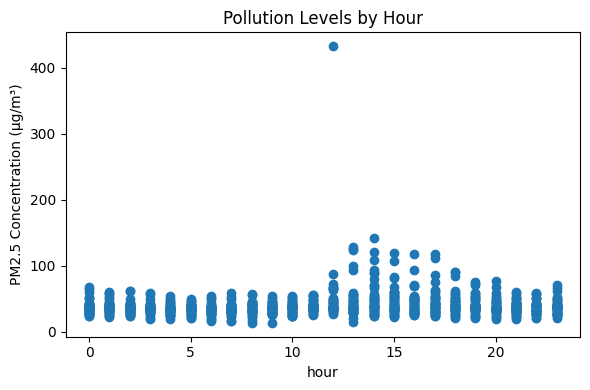

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(ready_hyd_df["hour"], ready_hyd_df["PM2.5 (ug/m3)"])

plt.xlabel("hour")
plt.ylabel("PM2.5 Concentration (µg/m³)")
plt.title("Pollution Levels by Hour")

plt.tight_layout()
plt.show()

This is the data I will strive to create a regression model for. It is not ideal for regression as there does not appear to be a clear pattern between the visualized variables, despite the sufficient amount of data points (>100 data samples spanning 4 days) and the appropriate question.

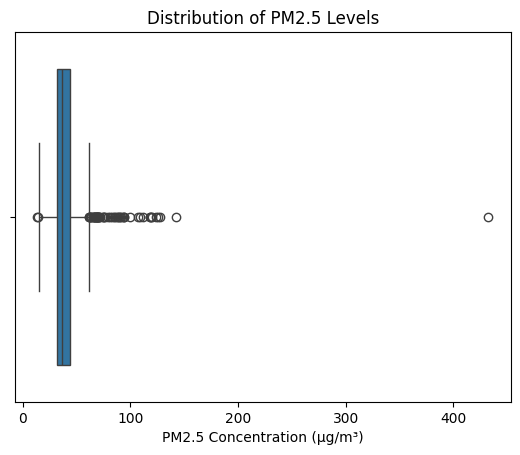

In [ ]:
#Checked for outliers with this boxplot
import seaborn as sns

sns.boxplot(x=ready_hyd_df["PM2.5 (ug/m3)"])

plt.xlabel("PM2.5 Concentration (µg/m³)")
plt.title("Distribution of PM2.5 Levels")

plt.show()